# 🏎️ F1 Data Analyser
## Analisi Esplorativa dei Dati (EDA)

---

### Obiettivo
Esplorare il dataset F1 per:
- Comprendere struttura e qualità dei dati
- Identificare pattern nelle strategie pit
- Analizzare distribuzione compound
- Generare insights per feature engineering
- **Pulire e preparare i dati per il training**

### Prerequisiti
- `f1_dataset_combined.pkl` (da notebook DataLoader)

### Output
| File | Descrizione |
|------|-------------|
| `f1_dataset_clean.pkl` | Dataset pulito per training |
| `Analysis/` | Grafici salvati |



# 1. Setup e Import Dataset

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os, sys
import json

# ML tools
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [4]:
# Uso della libreria Open FastF1
import importlib.util
if importlib.util.find_spec('fastf1') is None:
    !pip install fastf1 --quiet

df_f1 = pd.read_pickle('f1_dataset_combined.pkl')

In [5]:
def save_plot(fig, subfolder_name, filename):

    main_directory = 'Analysis'
    directory = os.path.join(main_directory, subfolder_name)

    if not os.path.exists(directory):
        os.makedirs(directory)

    file_path = os.path.join(directory, filename)
    fig.savefig(file_path, bbox_inches='tight')

    print(f"Grafico salvato in: {file_path}")

## Modifiche e Conversioni

In [6]:
# CONVERSIONE TIMEDELTA in secondi
temporal_cols = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'PitOutTime', 'PitInTime']

for col in temporal_cols:
    if col in df_f1.columns:
        new_col = f'{col}Sec'
        df_f1[new_col] = df_f1[col].dt.total_seconds()

In [7]:
# UNIFICAZIONE NOMI TEAM (storico)
print(f"\nTeam: {df_f1['Team'].unique()}")

team_mapping = {
    # RB / Racing Bulls / AlphaTauri → Racing Bulls
    'RB': 'Racing Bulls',
    'AlphaTauri': 'Racing Bulls',

    # Kick Sauber / Alfa Romeo → Kick Sauber
    'Alfa Romeo': 'Kick Sauber'
}

df_f1['Team'] = df_f1['Team'].replace(team_mapping)

print("\nTeam unificati:")
print(f"   AlphaTauri + RB → Racing Bulls")
print(f"   Alfa Romeo → Kick Sauber")
print(f"\nTeam: {df_f1['Team'].unique()}")


Team: ['Ferrari' 'Red Bull Racing' 'Mercedes' 'Haas F1 Team' 'AlphaTauri'
 'Alpine' 'Williams' 'Alfa Romeo' 'Aston Martin' 'McLaren' 'RB'
 'Kick Sauber' 'Racing Bulls']

Team unificati:
   AlphaTauri + RB → Racing Bulls
   Alfa Romeo → Kick Sauber

Team: ['Ferrari' 'Red Bull Racing' 'Mercedes' 'Haas F1 Team' 'Racing Bulls'
 'Alpine' 'Williams' 'Kick Sauber' 'Aston Martin' 'McLaren']


## Pulizia Compound Non Validi

In [8]:
# PULIZIA COMPOUND NON VALIDI
# Rimuove righe con compound 'None', 'nan' o NaN
# Questi sono dati incompleti che causerebbero problemi nel training

valid_compounds = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']

print(f"Compound presenti prima della pulizia:")
print(df_f1['Compound'].value_counts(dropna=False))

# Conta righe da rimuovere
invalid_mask = ~df_f1['Compound'].isin(valid_compounds)
n_invalid = invalid_mask.sum()

# Rimuovi righe con compound non validi
df_f1 = df_f1[df_f1['Compound'].isin(valid_compounds)]

print(f"\nRimosse {n_invalid:,} righe con compound non validi")
print(f"\nCompound presenti dopo la pulizia:")
print(df_f1['Compound'].value_counts())

Compound presenti prima della pulizia:
Compound
HARD            39678
MEDIUM          31907
SOFT            10397
INTERMEDIATE     4468
None              383
nan               382
WET               307
Name: count, dtype: int64

Rimosse 765 righe con compound non validi

Compound presenti dopo la pulizia:
Compound
HARD            39678
MEDIUM          31907
SOFT            10397
INTERMEDIATE     4468
WET               307
Name: count, dtype: int64


# 2. Analisi dei Dati

## Metriche base

In [9]:
# Overview
print(f"📦 Dimensioni Dataset:")
print(f"   Righe (giri):        {len(df_f1):,}")
print(f"   Colonne (features):  {len(df_f1.columns)}")

print(f"\n📅 Copertura Temporale:")
years = sorted(df_f1['Year'].unique())
print(f"   Anni:                {years}")
for year in years:
    n_races = df_f1[df_f1['Year'] == year]['Round'].nunique()
    n_laps = len(df_f1[df_f1['Year'] == year])
    print(f"   {year}: {n_races:2d} gare, {n_laps:,} giri")

print(f"\n🏁 Entità:")
print(f"   Gare totali:         {len(df_f1.groupby(['Year', 'Round']))}")
print(f"   Piloti unici:        {df_f1['Driver'].nunique()}")
print(f"   Team unici:          {df_f1['Team'].nunique()}")
print(f"   Circuiti unici:      {df_f1['Circuit'].nunique()}")

📦 Dimensioni Dataset:
   Righe (giri):        86,757
   Colonne (features):  55

📅 Copertura Temporale:
   Anni:                [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
   2022: 22 gare, 19,344 giri
   2023: 22 gare, 21,248 giri
   2024: 24 gare, 23,557 giri
   2025: 24 gare, 22,608 giri

🏁 Entità:
   Gare totali:         92
   Piloti unici:        31
   Team unici:          10
   Circuiti unici:      26


In [10]:
# Tipi di Dati (colonne presenti)
print(f"🔍 Tipi di Dati:\n")
for col in df_f1.columns:
    print(f"{col:30s}: {df_f1[col].dtype}")

🔍 Tipi di Dati:

Time                          : timedelta64[ns]
Driver                        : object
DriverNumber                  : object
LapTime                       : timedelta64[ns]
LapNumber                     : float64
Stint                         : float64
PitOutTime                    : timedelta64[ns]
PitInTime                     : timedelta64[ns]
Sector1Time                   : timedelta64[ns]
Sector2Time                   : timedelta64[ns]
Sector3Time                   : timedelta64[ns]
Sector1SessionTime            : timedelta64[ns]
Sector2SessionTime            : timedelta64[ns]
Sector3SessionTime            : timedelta64[ns]
SpeedI1                       : float64
SpeedI2                       : float64
SpeedFL                       : float64
SpeedST                       : float64
IsPersonalBest                : object
Compound                      : object
TyreLife                      : float64
FreshTyre                     : bool
Team                          

In [11]:
# Conteggio valori mancanti
print("❓ Valori Mancanti:")

missing = df_f1.isnull().sum()
missing_pct = (missing / len(df_f1) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentuale': missing_pct
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

print(f"\nColonne con valori mancanti: {len(missing_df)}/{len(df_f1.columns)}\n")
print(missing_df.head(20))

❓ Valori Mancanti:

Colonne con valori mancanti: 11/55

                    Missing  Percentuale
PitOutTime            86757       100.00
PitInTime             86757       100.00
PitOutTimeSec         86757       100.00
LapStartDate          86757       100.00
PitInTimeSec          86757       100.00
SpeedI1               14777        17.03
SpeedST                7064         8.14
SpeedI2                 782         0.90
Sector1SessionTime      210         0.24
TyreLife                183         0.21
SpeedFL                   4         0.00


In [12]:
# Distribuzione dei Piloti
print(df_f1["Driver"].unique())

['LEC' 'VER' 'SAI' 'HAM' 'MAG' 'PER' 'RUS' 'GAS' 'ALO' 'OCO' 'ALB' 'TSU'
 'MSC' 'BOT' 'HUL' 'STR' 'NOR' 'ZHO' 'LAT' 'RIC' 'VET' 'DEV' 'SAR' 'PIA'
 'LAW' 'BEA' 'COL' 'DOO' 'ANT' 'BOR' 'HAD']


In [13]:
# Distribuzione dei Team
print(df_f1["Team"].unique())

['Ferrari' 'Red Bull Racing' 'Mercedes' 'Haas F1 Team' 'Racing Bulls'
 'Alpine' 'Williams' 'Kick Sauber' 'Aston Martin' 'McLaren']


In [14]:
# Distribuzione dei Circuiti
print(df_f1["Circuit"].unique())

['Sakhir' 'Jeddah' 'Melbourne' 'Imola' 'Miami' 'Barcelona' 'Monaco' 'Baku'
 'Montréal' 'Silverstone' 'Spielberg' 'Le Castellet' 'Budapest'
 'Spa-Francorchamps' 'Zandvoort' 'Monza' 'Marina Bay' 'Suzuka' 'Austin'
 'Mexico City' 'São Paulo' 'Yas Island' 'Lusail' 'Las Vegas' 'Shanghai'
 'Miami Gardens']


In [15]:
# Distribuzione delle Gomme Pirelli
print(df_f1["Compound"].unique())

['SOFT' 'MEDIUM' 'HARD' 'INTERMEDIATE' 'WET']


In [16]:
# Statistiche LapTime
print(f"Statistiche Lap Time:\n")
if 'LapTimeSec' in df_f1.columns:
    # Filtra outlier (< 60s o > 200s sono pit lane / safety car)
    valid_laps = df_f1[(df_f1['LapTimeSec'] > 60) & (df_f1['LapTimeSec'] < 200)]

    print(f"   Giri totali:         {len(df_f1):,}")
    print(f"   Giri validi:         {len(valid_laps):,} ({len(valid_laps)/len(df_f1)*100:.1f}%)")
    print(f"   Min:                 {valid_laps['LapTimeSec'].min():.2f}s")
    print(f"   Max:                 {valid_laps['LapTimeSec'].max():.2f}s")
    print(f"   Media:               {valid_laps['LapTimeSec'].mean():.2f}s")
    print(f"   Mediana:             {valid_laps['LapTimeSec'].median():.2f}s")
    print(f"   Std Dev:             {valid_laps['LapTimeSec'].std():.2f}s")

Statistiche Lap Time:

   Giri totali:         86,757
   Giri validi:         86,757 (100.0%)
   Min:                 67.01s
   Max:                 149.32s
   Media:               89.09s
   Mediana:             87.38s
   Std Dev:             10.93s


In [17]:
# Safety Car e Interruzioni

print(f"   Giri sotto SC:      {df_f1['UnderSC'].sum():,} ({df_f1['UnderSC'].mean()*100:.2f}%)")
print(f"   Giri sotto VSC:     {df_f1['UnderVSC'].sum():,} ({df_f1['UnderVSC'].mean()*100:.2f}%)")
print(f"   Giri sotto caution: {df_f1['UnderCaution'].sum():,} ({df_f1['UnderCaution'].mean()*100:.2f}%)")

# Feature Yellow Flag (da TrackStatus)
df_f1['HasYellowFlag'] = df_f1['TrackStatus'].apply(
    lambda x: 1 if '2' in str(x) else 0
)
print(f"   Giri con Yellow: {df_f1['HasYellowFlag'].sum():,} ({df_f1['HasYellowFlag'].mean()*100:.2f}%)")

   Giri sotto SC:      17,502 (20.17%)
   Giri sotto VSC:     0 (0.00%)
   Giri sotto caution: 17,502 (20.17%)
   Giri con Yellow: 2,689 (3.10%)


In [18]:
# Analisi Speed Traps

print("📊 STATISTICHE SPEED TRAPS")
print("=" * 60)

speed_cols = ['SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']

for col in speed_cols:
    if col in df_f1.columns:
        valid = df_f1[col].notna().sum()
        pct = valid / len(df_f1) * 100
        print(f"\n{col}:")
        print(f"   Valori validi: {valid:,} ({pct:.1f}%)")
        print(f"   Min: {df_f1[col].min():.1f} km/h")
        print(f"   Max: {df_f1[col].max():.1f} km/h")
        print(f"   Media: {df_f1[col].mean():.1f} km/h")
        print(f"   Std: {df_f1[col].std():.1f} km/h")

📊 STATISTICHE SPEED TRAPS

SpeedI1:
   Valori validi: 71,980 (83.0%)
   Min: 60.0 km/h
   Max: 357.0 km/h
   Media: 258.0 km/h
   Std: 44.6 km/h

SpeedI2:
   Valori validi: 85,975 (99.1%)
   Min: 79.0 km/h
   Max: 344.0 km/h
   Media: 251.7 km/h
   Std: 41.6 km/h

SpeedFL:
   Valori validi: 86,753 (100.0%)
   Min: 69.0 km/h
   Max: 359.0 km/h
   Media: 269.0 km/h
   Std: 32.5 km/h

SpeedST:
   Valori validi: 79,693 (91.9%)
   Min: 100.0 km/h
   Max: 364.0 km/h
   Media: 302.7 km/h
   Std: 18.6 km/h


## Metriche Approfondite

### Analisi Piloti

Grafico salvato in: Analysis/DriverAnalysis/driver_rank_laps


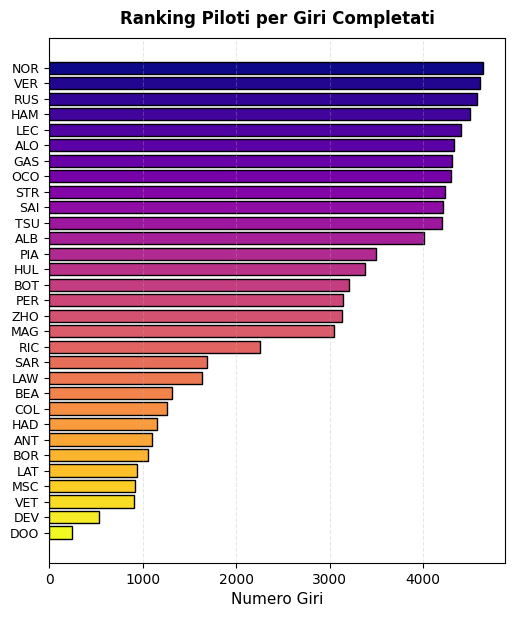

In [19]:
# Ranking Piloti per Giri Completati

fig = plt.figure(figsize=(20, 15))
ax = plt.subplot(2, 3, 1)
top_drivers = df_f1['Driver'].value_counts()
colors = plt.cm.plasma(np.linspace(0, 1, len(top_drivers)))
bars = ax.barh(range(len(top_drivers)), top_drivers.values, color=colors, edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top_drivers)))
ax.set_yticklabels(top_drivers.index, fontsize=9)
ax.set_xlabel('Numero Giri', fontsize=11)
ax.set_title('Ranking Piloti per Giri Completati', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

save_plot(fig, "DriverAnalysis", "driver_rank_laps")

Grafico salvato in: Analysis/DriverAnalysis/driver_position_distribution


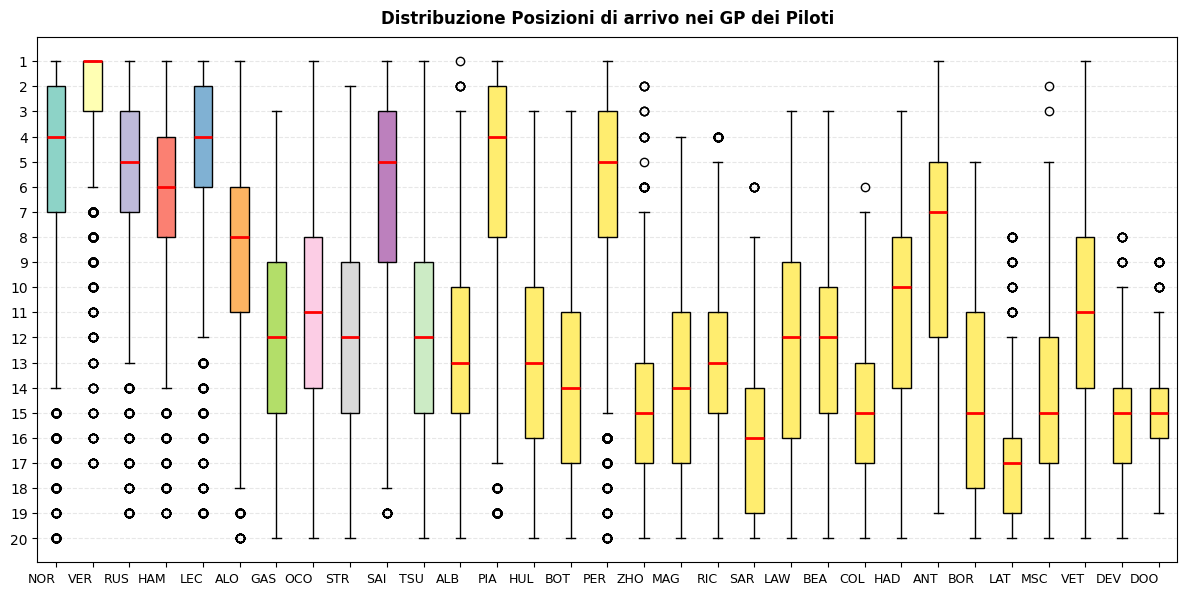

In [20]:
# Distribuzione delle Posizioni dei Piloti

fig = plt.figure(figsize=(50, 15))
ax = plt.subplot(2, 3, 3)
top_drivers = df_f1['Driver'].value_counts().index
data_to_plot = [df_f1[df_f1['Driver'] == driver]['Position'].dropna().values
                for driver in top_drivers]
bp = ax.boxplot(data_to_plot, labels=top_drivers, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(top_drivers)))):
    patch.set_facecolor(color)
ax.set_xticklabels(top_drivers, ha='right', fontsize=9)
ax.set_yticks(range(1, 21))
ax.set_title('Distribuzione Posizioni di arrivo nei GP dei Piloti', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')

save_plot(fig, "DriverAnalysis", "driver_position_distribution")

Grafico salvato in: Analysis/DriverAnalysis/driver_avg_position


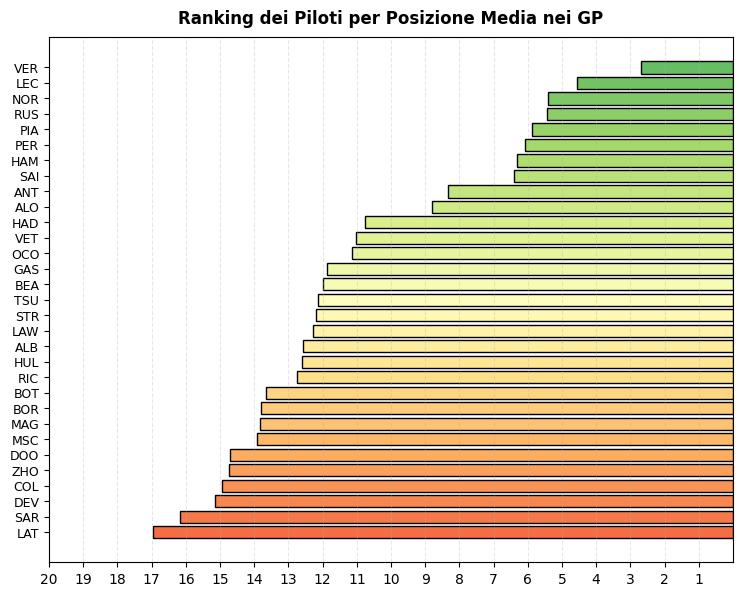

In [21]:
# Distribuzioni delle Medie Posizioni dei Piloti

fig = plt.figure(figsize=(30, 15))
ax = plt.subplot(2, 3, 5)
avg_position = df_f1.groupby('Driver')['Position'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(avg_position)))
bars = ax.barh(range(len(avg_position)), avg_position.values, color=colors,
                edgecolor='black', linewidth=1)
ax.set_yticks(range(len(avg_position)))
ax.set_yticklabels(avg_position.index, fontsize=9)
ax.set_xticks(range(1, 21))
ax.set_title('Ranking dei Piloti per Posizione Media nei GP', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.invert_xaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

save_plot(fig, "DriverAnalysis", "driver_avg_position")

Grafico salvato in: Analysis/DriverAnalysis/driver_participation_years


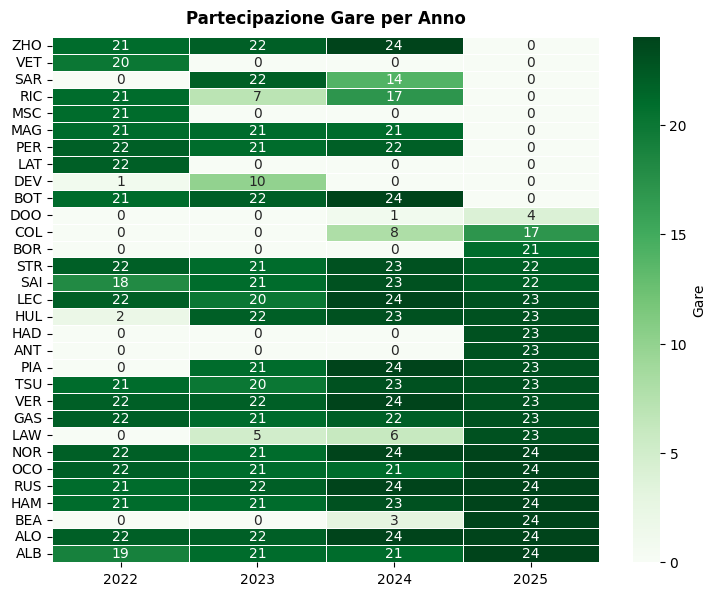

In [22]:
# Partecipazione dei Piloti alle Gare per ogni Anno

fig = plt.figure(figsize=(30, 15))
ax = plt.subplot(2, 3, 4)
ax.set_title('Partecipazione Gare per Anno', fontsize=12, fontweight='bold', pad=10)
participation = df_f1.groupby(['Year', 'Driver'])['Round'].nunique().reset_index()
participation_pivot = participation.pivot(index='Driver', columns='Year', values='Round').fillna(0)
participation_pivot = participation_pivot[participation_pivot.sum(axis=1) > 1].sort_values(
    by=participation_pivot.columns[-1], ascending=False)
sns.heatmap(participation_pivot, annot=True, fmt='.0f', cmap='Greens', ax=ax,
           linewidths=0.5, cbar_kws={'label': 'Gare'})
ax.set_xlabel('', fontsize=11, fontweight='bold')
ax.set_ylabel('', fontsize=11, fontweight='bold')
ax.invert_yaxis()

save_plot(fig, "DriverAnalysis", "driver_participation_years")

### Analisi Team

Grafico salvato in: Analysis/TeamAnalysis/team_rank_laps


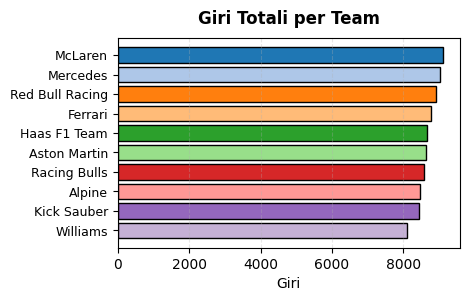

In [23]:
# Ranking Team per Giri Completati

fig = plt.figure(figsize=(15, 6))
ax = plt.subplot(2, 3, 3)
team_totals = df_f1['Team'].value_counts()
colors = plt.cm.tab20(range(len(team_totals)))
bars = ax.barh(range(len(team_totals)), team_totals.values, color=colors,
                edgecolor='black', linewidth=1)
ax.set_yticks(range(len(team_totals)))
ax.set_yticklabels(team_totals.index, fontsize=9)
ax.set_xlabel('Giri')
ax.set_title('Giri Totali per Team', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

save_plot(fig, "TeamAnalysis", "team_rank_laps")

Grafico salvato in: Analysis/TeamAnalysis/team_participation_years


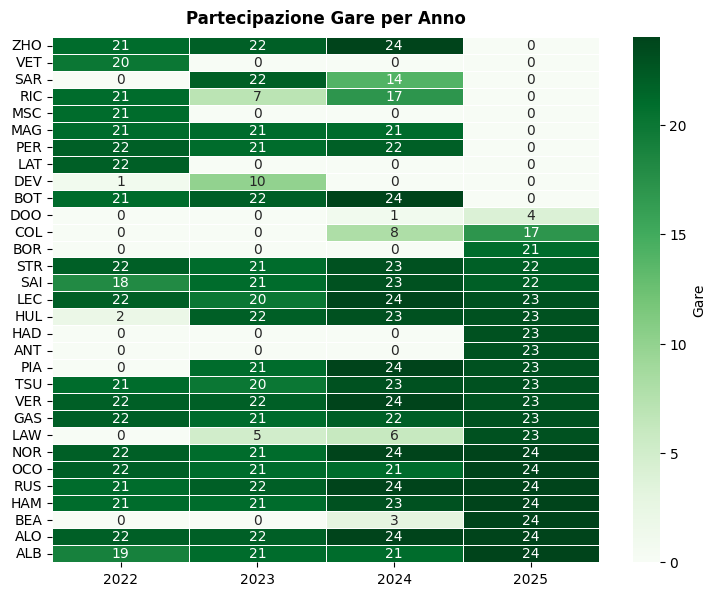

In [24]:
# Partecipazione dei Piloti alle Gare per ogni Anno

fig = plt.figure(figsize=(30, 15))
ax = plt.subplot(2, 3, 4)
ax.set_title('Partecipazione Gare per Anno', fontsize=12, fontweight='bold', pad=10)
participation = df_f1.groupby(['Year', 'Driver'])['Round'].nunique().reset_index()
participation_pivot = participation.pivot(index='Driver', columns='Year', values='Round').fillna(0)
participation_pivot = participation_pivot[participation_pivot.sum(axis=1) > 1].sort_values(
    by=participation_pivot.columns[-1], ascending=False)
sns.heatmap(participation_pivot, annot=True, fmt='.0f', cmap='Greens', ax=ax,
           linewidths=0.5, cbar_kws={'label': 'Gare'})
ax.set_xlabel('', fontsize=11, fontweight='bold')
ax.set_ylabel('', fontsize=11, fontweight='bold')
ax.invert_yaxis()

save_plot(fig, "TeamAnalysis", "team_participation_years")

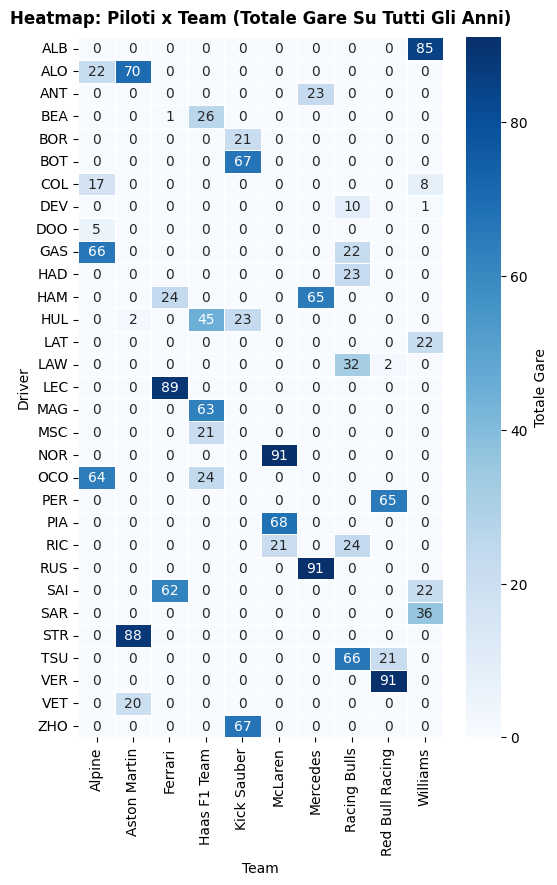

Grafico salvato in: Analysis/TeamAnalysis/team_participation_drivers


In [25]:
# Partecipazione dei Piloti alle Gare per ogni Team

fig = plt.figure(figsize=(20, 20))
ax = plt.subplot(2, 3, 4)
top_drivers = df_f1['Driver'].value_counts().index
pivot_driver_team = df_f1[df_f1['Driver'].isin(top_drivers)].pivot_table(
    values='Round',
    index=['Driver', 'Year'],
    columns='Team',
    aggfunc='nunique',
    fill_value=0
)
pivot_driver_team_total = pivot_driver_team.groupby(level='Driver').sum()
sns.heatmap(pivot_driver_team_total, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Totale Gare'})
ax.set_title('Heatmap: Piloti x Team (Totale Gare Su Tutti Gli Anni)', fontsize=12, fontweight='bold', pad=10)
plt.show()

save_plot(fig, "TeamAnalysis", "team_participation_drivers")

Grafico salvato in: Analysis/TeamAnalysis/team_position_distribution


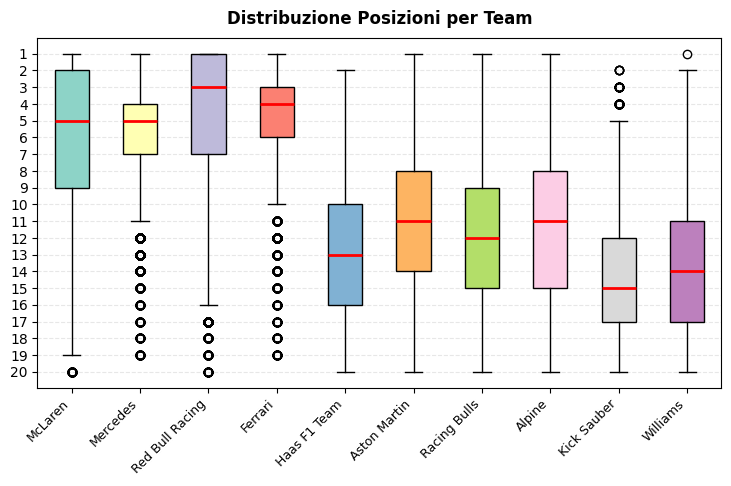

In [26]:
# Distribuzione delle Posizione nei GP per Team

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 5)
top_teams = df_f1['Team'].value_counts().index
data_to_plot = [df_f1[df_f1['Team'] == team]['Position'].dropna().values
                for team in top_teams]
bp = ax.boxplot(data_to_plot, labels=top_teams, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(top_teams)))):
    patch.set_facecolor(color)
ax.set_yticks(range(1, 21))
ax.set_xticklabels(top_teams, rotation=45, ha='right', fontsize=9)
ax.set_title('Distribuzione Posizioni per Team', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')

save_plot(fig, "TeamAnalysis", "team_position_distribution")

### Analisi Gomme

Grafico salvato in: Analysis/CompoundAnalysis/compound_distribution


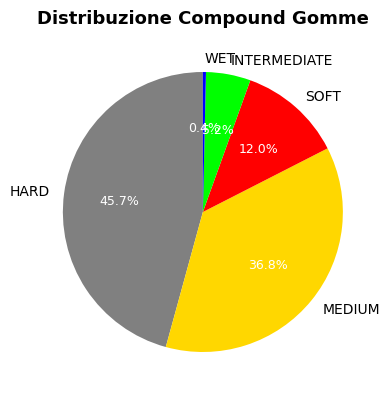

In [27]:
# Distribuzione Compound Utilizzati
fig = plt.figure(figsize=(30, 10))

ax = plt.subplot(2, 3, 4)
compound_colors = {
    'HARD': '#808080', 'WET': '#0000FF', 'MEDIUM': '#FFD700', 'SOFT': '#FF0000',
    'INTERMEDIATE': '#00FF00'}

compound_data = df_f1['Compound'].value_counts().dropna()
compound_data = compound_data[compound_data.index.isin(compound_colors.keys())]
colors = [compound_colors.get(c, '#CCCCCC') for c in compound_data.index]
wedges, texts, autotexts = ax.pie(compound_data.values, labels=compound_data.index,
                                    autopct='%1.1f%%', startangle=90, colors=colors,
                                    )
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
ax.set_title('Distribuzione Compound Gomme', fontsize=13, fontweight='bold', pad=10)

save_plot(fig, "CompoundAnalysis", "compound_distribution")

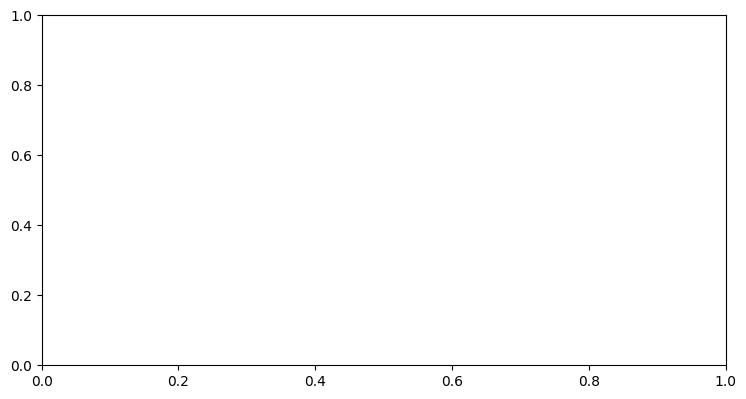

In [28]:
# Distribuzione Lunghezza Stint

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 2)
if 'StintLength' in df_f1.columns:
    stint_lengths = df_f1['StintLength'].dropna()
    stint_lengths = stint_lengths[(stint_lengths > 0) & (stint_lengths <= 60)]
    ax.hist(stint_lengths, bins=40, edgecolor='black', alpha=0.7, color='teal')
    mean_stint = stint_lengths.mean()
    median_stint = stint_lengths.median()
    ax.axvline(mean_stint, color='red', linestyle='--', linewidth=2,
               label=f'Media: {mean_stint:.1f} giri')
    ax.axvline(median_stint, color='green', linestyle='--', linewidth=2,
               label=f'Mediana: {median_stint:.1f} giri')
    ax.set_xlabel('Stint Length (giri)')
    ax.set_ylabel('Frequenza (di Stint Length)')
    ax.set_title('Distribuzione Lunghezza Stint', fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')

    save_plot(fig, "CompoundAnalysis", "stint_length_distribution")

Grafico salvato in: Analysis/CompoundAnalysis/compound_degradation


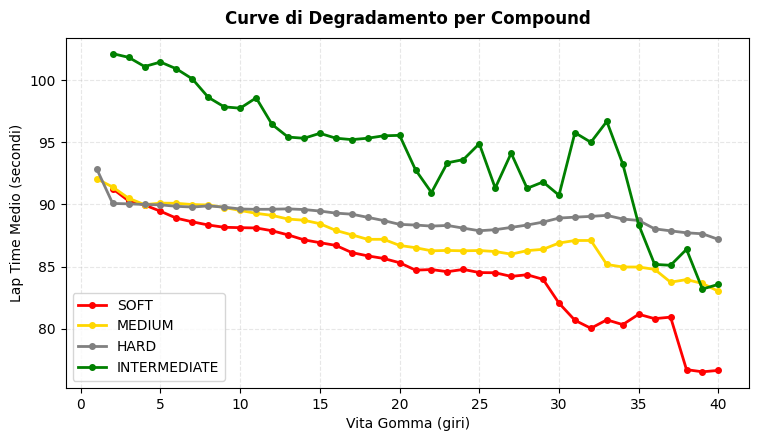

In [29]:
# Degradamento per Tipo di Gomma

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 1)
if 'LapTimeSec' in df_f1.columns and 'TyreLife' in df_f1.columns:
    for compound, color in [('SOFT', 'red'), ('MEDIUM', 'gold'), ('HARD', 'grey'), ('INTERMEDIATE', 'green')]:
        compound_data = df_f1[
            (df_f1['Compound'] == compound) &
            (df_f1['TyreLife'] <= 40)
        ]
        if len(compound_data) > 0:
            degradation = compound_data.groupby('TyreLife')['LapTimeSec'].mean()
            ax.plot(degradation.index, degradation.values,
                    marker='o', label=compound, color=color, linewidth=2, markersize=4)
    ax.set_xlabel('Vita Gomma (giri)')
    ax.set_ylabel('Lap Time Medio (secondi)')
    ax.set_title('Curve di Degradamento per Compound', fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

    save_plot(fig, "CompoundAnalysis", "compound_degradation")

Grafico salvato in: Analysis/CompoundAnalysis/compound_tyrelife_distribution


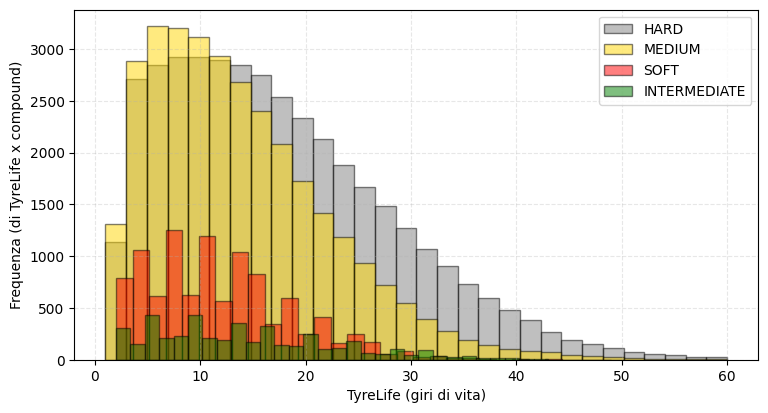

In [30]:
# Frequenza del Numero di Giri Compiuti per ogni Compound

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 4)
if 'TyreLife' in df_f1.columns:
    for compound, color in [ ('HARD', 'grey'), ('MEDIUM', 'gold'), ('SOFT', 'red'), ('INTERMEDIATE', 'green')]:
        compound_tyrelife = df_f1[df_f1['Compound'] == compound]['TyreLife'].dropna()
        compound_tyrelife = compound_tyrelife[compound_tyrelife <= 60]
        ax.hist(compound_tyrelife, bins=30, alpha=0.5, label=compound,
                color=color, edgecolor='black')
    ax.set_xlabel('TyreLife (giri di vita)')
    ax.set_ylabel('Frequenza (di TyreLife x compound)')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')

    save_plot(fig, "CompoundAnalysis", "compound_tyrelife_distribution")

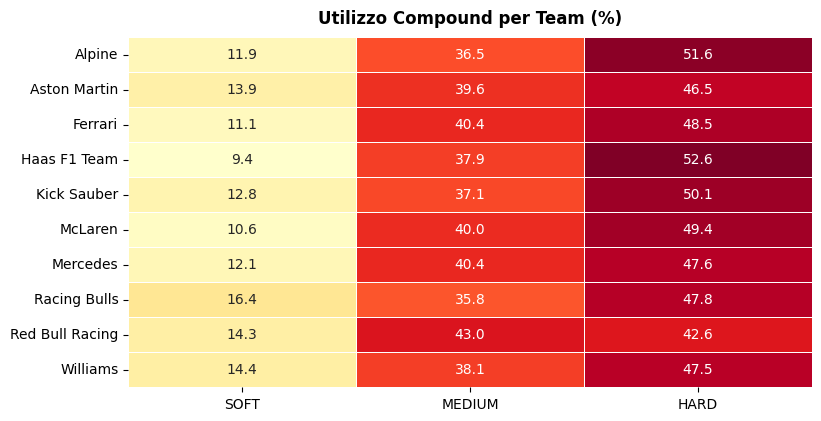

Grafico salvato in: Analysis/CompoundAnalysis/compound_usage_team


In [31]:
# Gomma Usata per Team

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 5)

top_teams = df_f1['Team'].value_counts().index
compound_usage = df_f1[df_f1['Team'].isin(top_teams)].pivot_table(
    values='LapNumber', index='Team', columns='Compound', aggfunc='count', fill_value=0
)
for col in ['SOFT','MEDIUM','HARD']:
    if col not in compound_usage.columns:
        compound_usage[col] = 0
compound_usage = compound_usage[['SOFT','MEDIUM','HARD']]

compound_percentage = compound_usage.div(compound_usage.sum(axis=1), axis=0) * 100
sns.heatmap(compound_percentage, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar=False)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title('Utilizzo Compound per Team (%)', fontsize=12, fontweight='bold', pad=10)
plt.show()

save_plot(fig, "CompoundAnalysis", "compound_usage_team")

### Analisi Meteo

Grafico salvato in: Analysis/WeatherAnalysis/weather_distribution


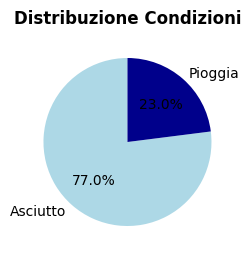

In [32]:
# Pioggia o Asciutto

fig = plt.figure(figsize=(15, 6))
ax = plt.subplot(2, 3, 6)
if 'Rainfall' in df_f1.columns:
    rainfall_counts = df_f1['Rainfall'].value_counts()
    colors_rain = ['lightblue', 'darkblue']
    ax.pie(rainfall_counts.values, labels=['Asciutto', 'Pioggia'],
           autopct='%1.1f%%', startangle=90, colors=colors_rain)
    ax.set_title('Distribuzione Condizioni', fontsize=12, fontweight='bold', pad=10)

    save_plot(fig, "WeatherAnalysis", "weather_distribution")

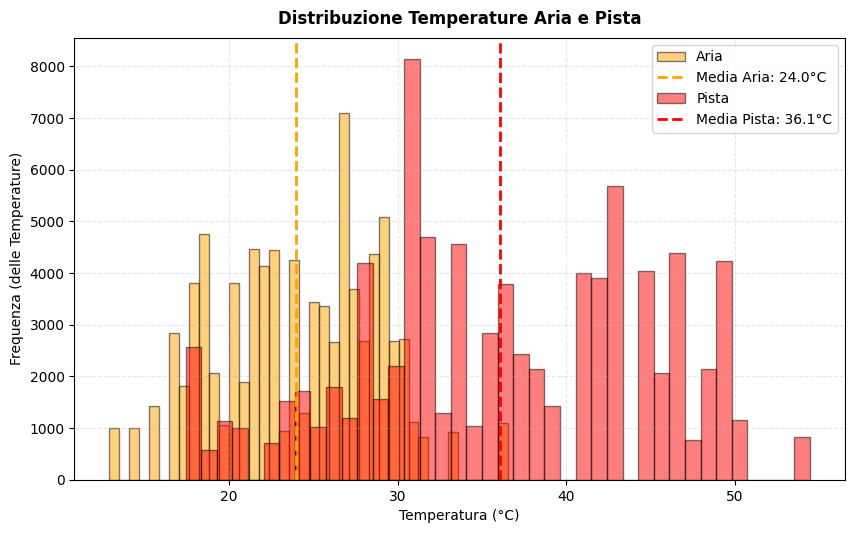

Grafico salvato in: Analysis/WeatherAnalysis/weather_temperature


In [33]:
# Temperatura Aria e Pista

fig = plt.figure(figsize=(25, 10))
ax = plt.subplot(2, 3, 3)

if 'AirTemp' in df_f1.columns:
    ax.hist(df_f1['AirTemp'], bins=40, edgecolor='black', alpha=0.5, color='orange', label='Aria')
    mean_temp = df_f1['AirTemp'].mean()
    ax.axvline(mean_temp, color='orange', linestyle='--', linewidth=2,
               label=f'Media Aria: {mean_temp:.1f}°C')

if 'TrackTemp' in df_f1.columns:
    ax.hist(df_f1['TrackTemp'], bins=40, edgecolor='black', alpha=0.5, color='red', label='Pista')
    mean_track = df_f1['TrackTemp'].mean()
    ax.axvline(mean_track, color='red', linestyle='--', linewidth=2,
               label=f'Media Pista: {mean_track:.1f}°C')

ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Frequenza (delle Temperature)')
ax.set_title('Distribuzione Temperature Aria e Pista', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

save_plot(fig, "WeatherAnalysis", "weather_temperature")

Grafico salvato in: Analysis/WeatherAnalysis/weather_windspeed


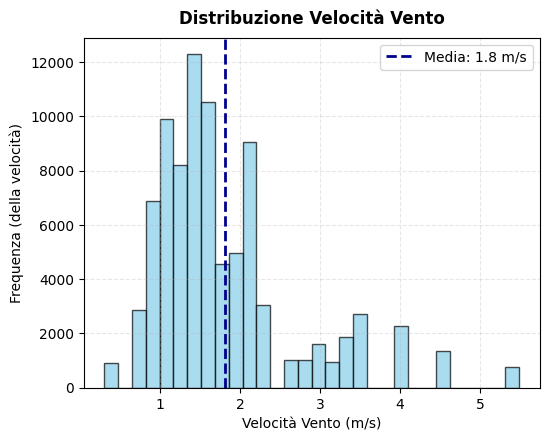

In [34]:
# Velocità del Vento

fig = plt.figure(figsize=(20, 10))
ax = plt.subplot(2, 3, 5)
if 'WindSpeed' in df_f1.columns:
    ax.hist(df_f1['WindSpeed'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    mean_wind = df_f1['WindSpeed'].mean()
    ax.axvline(mean_wind, color='darkblue', linestyle='--', linewidth=2,
               label=f'Media: {mean_wind:.1f} m/s')
    ax.set_xlabel('Velocità Vento (m/s)')
    ax.set_ylabel('Frequenza (della velocità)')
    ax.set_title('Distribuzione Velocità Vento', fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')

    save_plot(fig, "WeatherAnalysis", "weather_windspeed")

Grafico salvato in: Analysis/WeatherAnalysis/weather_temp_vs_laptime


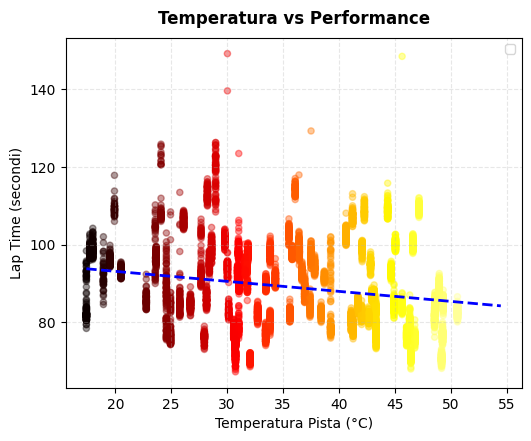

In [35]:
# Relazione Temperatura vs Lap Time

fig = plt.figure(figsize=(20, 10))
ax = plt.subplot(2, 3, 3)
if 'TrackTemp' in df_f1.columns and 'LapTimeSec' in df_f1.columns:
    sample_data = df_f1.sample(min(9000, len(df_f1)))
    scatter = ax.scatter(sample_data['TrackTemp'], sample_data['LapTimeSec'],
                        c=sample_data['TrackTemp'], cmap='hot', alpha=0.4, s=20)
    z = np.polyfit(sample_data['TrackTemp'], sample_data['LapTimeSec'], 1)
    p = np.poly1d(z)
    ax.plot(sorted(sample_data['TrackTemp']), p(sorted(sample_data['TrackTemp'])),
            "b--", linewidth=2)
    ax.set_xlabel('Temperatura Pista (°C)')
    ax.set_ylabel('Lap Time (secondi)')
    ax.set_title('Temperatura vs Performance', fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

save_plot(fig, "WeatherAnalysis", "weather_temp_vs_laptime")

### Analisi Circuiti

Grafico salvato in: Analysis/CircuitAnalysis/circuit_laptime


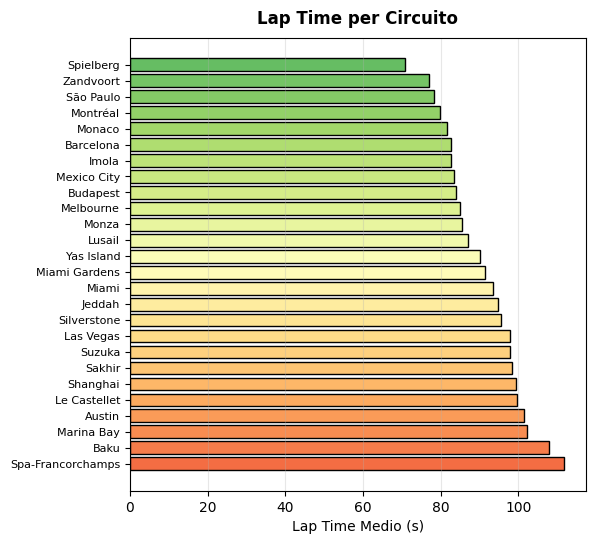

In [36]:
# Lap Time medio per Circuito

fig = plt.figure(figsize=(20, 20))
ax = plt.subplot(3, 3, 2)
top_circuits = df_f1['Circuit'].value_counts().index
circuit_laptimes = valid_laps[valid_laps['Circuit'].isin(top_circuits)].groupby('Circuit')['LapTimeSec'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(circuit_laptimes)))
ax.barh(range(len(circuit_laptimes)), circuit_laptimes.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(circuit_laptimes)))
ax.set_yticklabels(circuit_laptimes.index, fontsize=8)
ax.set_xlabel('Lap Time Medio (s)')
ax.set_title('Lap Time per Circuito', fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_laptime")

Grafico salvato in: Analysis/CircuitAnalysis/circuit_count


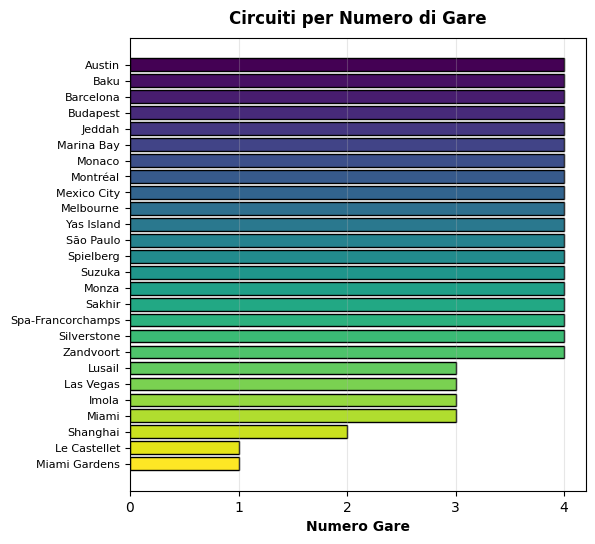

In [37]:
# Gare per Circuito nei 4 anni
fig = plt.figure(figsize=(20, 20))

ax = plt.subplot(3, 3, 1)
circuit_counts = df_f1.groupby('Circuit').apply(lambda x: x[['Year','Round']].drop_duplicates().shape[0]).sort_values(ascending=False)

colors = plt.cm.viridis(np.linspace(0, 1, len(circuit_counts)))

ax.barh(range(len(circuit_counts)), circuit_counts.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(circuit_counts)))
ax.set_yticklabels(circuit_counts.index, fontsize=8)
ax.set_xlabel('Numero Gare', fontweight='bold')
ax.set_title('Circuiti per Numero di Gare', fontweight='bold', pad=10)
ax.set_xticks(range(0, circuit_counts.max() + 1))

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_count")

Grafico salvato in: Analysis/CircuitAnalysis/circuit_temp


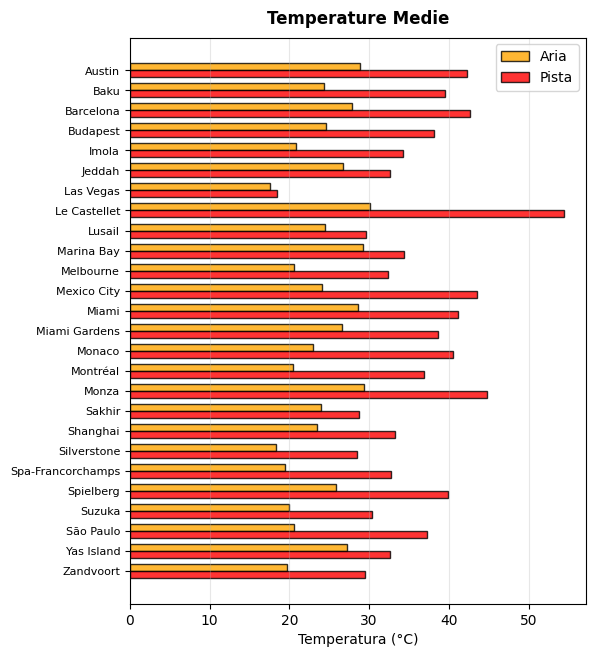

In [38]:
# Temperatura Media per Circuito
fig = plt.figure(figsize=(20, 25))

ax = plt.subplot(3, 3, 4)
circuit_temp = df_f1[df_f1['Circuit'].isin(top_circuits)].groupby('Circuit')[['AirTemp', 'TrackTemp']].mean()
x = np.arange(len(circuit_temp))
width = 0.35
ax.barh(x - width/2, circuit_temp['AirTemp'], width, label='Aria', color='orange', alpha=0.8, edgecolor='black')
ax.barh(x + width/2, circuit_temp['TrackTemp'], width, label='Pista', color='red', alpha=0.8, edgecolor='black')
ax.set_yticks(x)
ax.set_yticklabels(circuit_temp.index, fontsize=8)
ax.set_xlabel('Temperatura (°C)')
ax.set_title('Temperature Medie', fontweight='bold', pad=10)
ax.legend()
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_temp")

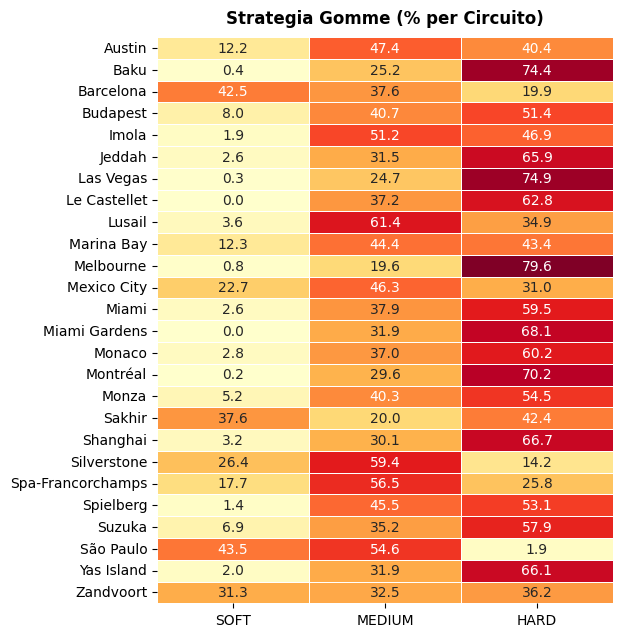

Grafico salvato in: Analysis/CircuitAnalysis/circuit_compound_usage


In [39]:
# Strategia Gomme per Circuito (in % per i vari anni)

fig = plt.figure(figsize=(20, 25))
ax = plt.subplot(3, 3, 6)

top_circuits = df_f1['Circuit'].value_counts().index
compound_usage = df_f1[df_f1['Circuit'].isin(top_circuits)].pivot_table(
    values='LapNumber', index='Circuit', columns='Compound', aggfunc='count', fill_value=0
)

for col in ['SOFT','MEDIUM','HARD']:
    if col not in compound_usage.columns:
        compound_usage[col] = 0
compound_usage = compound_usage[['SOFT','MEDIUM','HARD']]
compound_percentage = compound_usage.div(compound_usage.sum(axis=1), axis=0) * 100
sns.heatmap(compound_percentage, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar=False)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title('Strategia Gomme (% per Circuito)', fontweight='bold', pad=10)
plt.show()

save_plot(fig, "CircuitAnalysis", "circuit_compound_usage")

Grafico salvato in: Analysis/CircuitAnalysis/circuit_stint_length


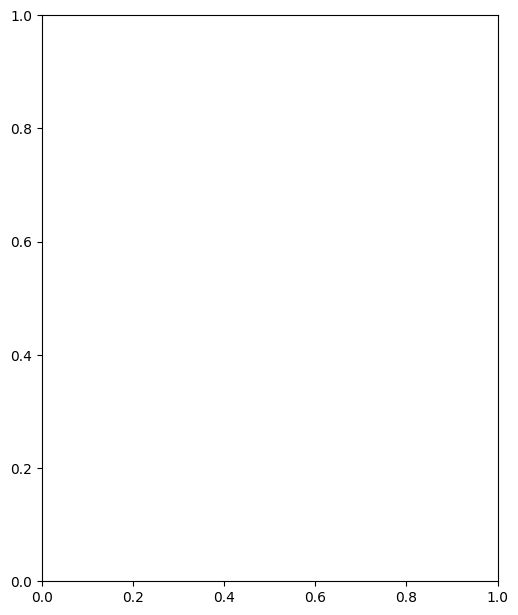

In [40]:
# Stint Length Medio per Circuito
fig = plt.figure(figsize=(20, 25))

ax = plt.subplot(3, 3, 7)
if 'StintLength' in df_f1.columns:
    stint_by_circuit = df_f1[df_f1['Circuit'].isin(top_circuits)].groupby('Circuit')['StintLength'].mean().sort_values(ascending=False)
    colors = plt.cm.plasma(np.linspace(0, 1, len(stint_by_circuit)))
    ax.barh(range(len(stint_by_circuit)), stint_by_circuit.values, color=colors, edgecolor='black')
    ax.set_yticks(range(len(stint_by_circuit)))
    ax.set_yticklabels(stint_by_circuit.index, fontsize=8)
    ax.set_xlabel('Stint Length Medio (giri)')
    ax.set_title('Lunghezza Stint Media per Circuito', fontweight='bold', pad=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_stint_length")

Grafico salvato in: Analysis/CircuitAnalysis/circuit_weather


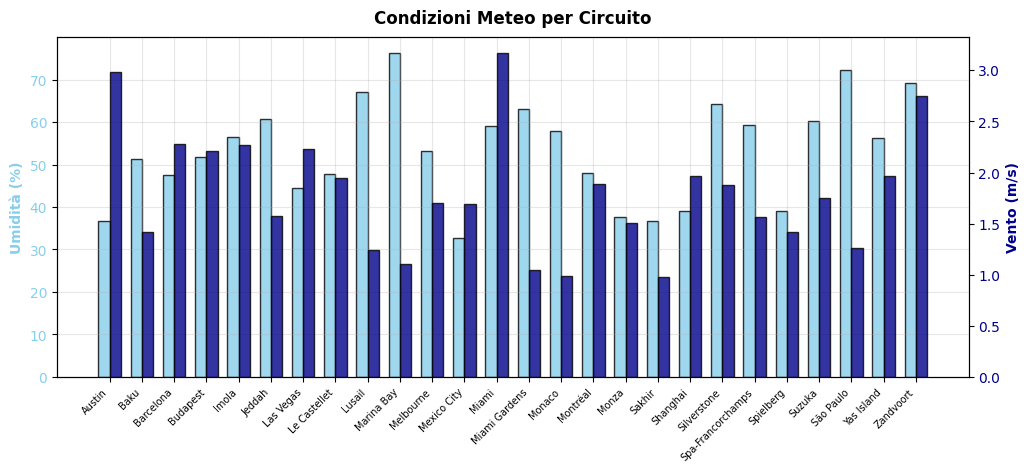

In [41]:
# Umidità e Vento per Circuito
fig = plt.figure(figsize=(40, 15))

ax = plt.subplot(3, 3, 8)
circuit_weather = df_f1[df_f1['Circuit'].isin(top_circuits)].groupby('Circuit')[['Humidity', 'WindSpeed']].mean()
x = np.arange(len(circuit_weather))
ax_twin = ax.twinx()
ax.bar(x - width/2, circuit_weather['Humidity'], width, label='Umidità', color='skyblue', alpha=0.8, edgecolor='black')
ax_twin.bar(x + width/2, circuit_weather['WindSpeed'], width, label='Vento', color='darkblue', alpha=0.8, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(circuit_weather.index, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Umidità (%)', fontweight='bold', color='skyblue')
ax_twin.set_ylabel('Vento (m/s)', fontweight='bold', color='darkblue')
ax.set_title('Condizioni Meteo per Circuito', fontweight='bold', pad=10)
ax.tick_params(axis='y', labelcolor='skyblue')
ax_twin.tick_params(axis='y', labelcolor='darkblue')
ax.grid(alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_weather")

### Analisi Gara

Grafico salvato in: Analysis/SafetyCarAnalysis/safety_car_status


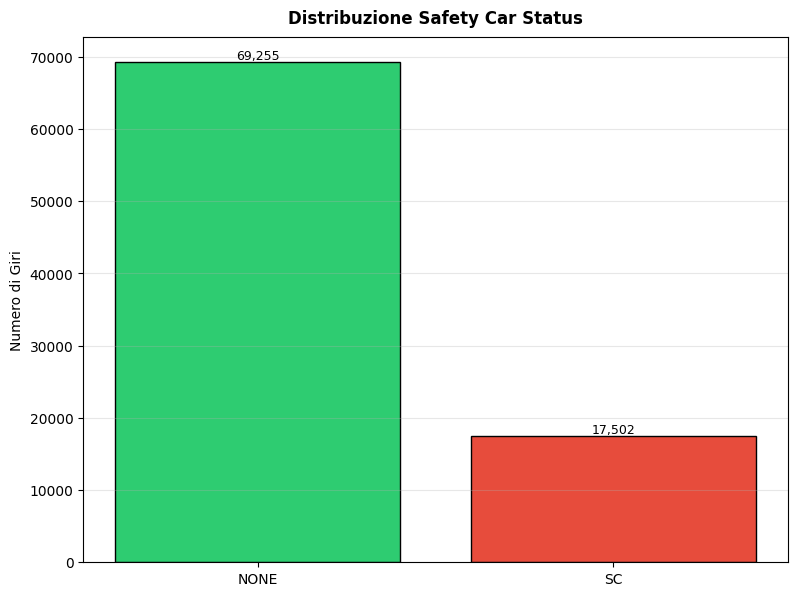

In [42]:
# Distribuzione SC/VSC
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1)
if 'SafetyCarStatus' in df_f1.columns and df_f1['UnderCaution'].sum() > 0:
    sc_counts = df_f1['SafetyCarStatus'].value_counts()
    colors = {'NONE': '#2ecc71', 'SC': '#e74c3c', 'VSC': '#f39c12'}
    bar_colors = [colors.get(x, '#95a5a6') for x in sc_counts.index]
    bars = ax.bar(sc_counts.index, sc_counts.values, color=bar_colors, edgecolor='black')
    ax.set_ylabel('Numero di Giri')
    ax.set_title('Distribuzione Safety Car Status', fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, count in zip(bars, sc_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

save_plot(fig, "SafetyCarAnalysis", "safety_car_status")

Grafico salvato in: Analysis/SafetyCarAnalysis/safety_car_by_circuit


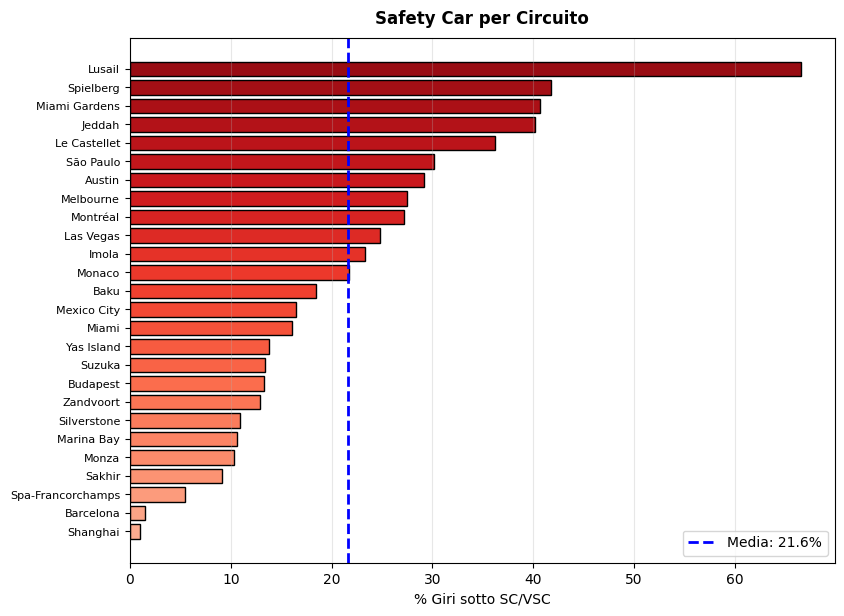

In [43]:
# % SC/VSC per Circuito
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 2)
if df_f1['UnderCaution'].sum() > 0:
    caution_by_circuit = df_f1.groupby('Circuit')['UnderCaution'].mean().sort_values() * 100
    colors2 = plt.cm.Reds(np.linspace(0.3, 0.9, len(caution_by_circuit)))
    ax.barh(range(len(caution_by_circuit)), caution_by_circuit.values, color=colors2, edgecolor='black')
    ax.set_yticks(range(len(caution_by_circuit)))
    ax.set_yticklabels(caution_by_circuit.index, fontsize=8)
    ax.set_xlabel('% Giri sotto SC/VSC')
    ax.set_title('Safety Car per Circuito', fontweight='bold', pad=10)
    ax.grid(axis='x', alpha=0.3)
    mean_caution = caution_by_circuit.mean()
    ax.axvline(mean_caution, color='blue', linestyle='--', linewidth=2, label=f'Media: {mean_caution:.1f}%')
    ax.legend(loc='lower right')

save_plot(fig, "SafetyCarAnalysis", "safety_car_by_circuit")

Grafico salvato in: Analysis/SafetyCarAnalysis/safety_car_by_season


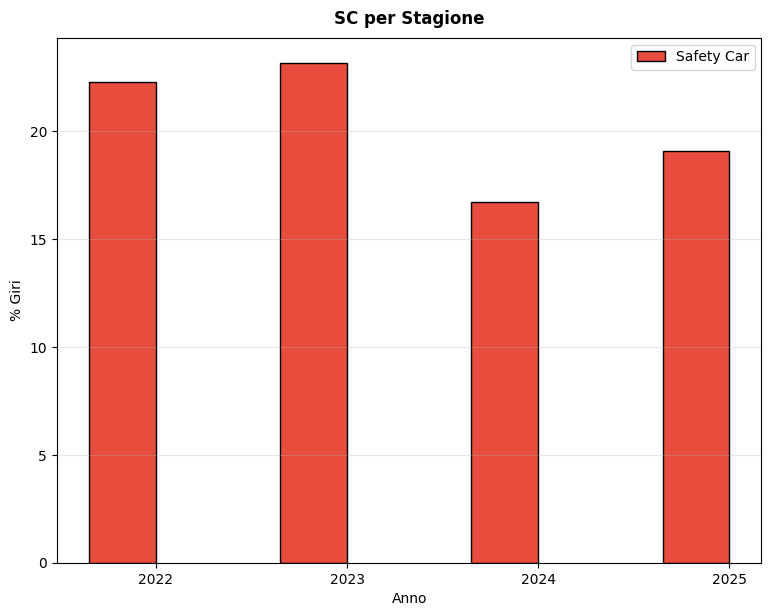

In [55]:
# SC/VSC per Anno
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 3)
if df_f1['UnderCaution'].sum() > 0:
    sc_by_year = df_f1.groupby('Year').agg({
        'UnderSC': 'mean',
    }) * 100
    x = np.arange(len(sc_by_year))
    width = 0.35
    # Corrected: Changed 'UnderCaution' to 'UnderSC'
    ax.bar(x - width/2, sc_by_year['UnderSC'], width, label='Safety Car', color='#e74c3c', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(sc_by_year.index.astype(str))
    ax.set_xlabel('Anno')
    ax.set_ylabel('% Giri')
    ax.set_title('SC per Stagione', fontweight='bold', pad=10)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

save_plot(fig, "SafetyCarAnalysis", "safety_car_by_season")

---
# 3. Salvataggio Dataset Pulito

Il dataset è stato elaborato con le seguenti modifiche:
1. **Conversione Timedelta -> secondi** (colonne `*Sec`)
2. **Unificazione nomi team** storici
3. **Rimozione righe** con compound non validi

Il pickle viene salvato per essere usato direttamente nel notebook LSTM.

In [46]:
output_filename = 'f1_dataset_clean.pkl'
df_f1.to_pickle(output_filename)